# Part 4: Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)

## 1. Load Models

In [2]:
# Simple model (Part 2) - Logistic Regression pipeline (CountVectorizer + LR combined)
lr_pipeline = joblib.load("models/logistic_regression_pipeline.pkl")

# Advanced model (Part 3) - Linear SVM + TF-IDF
svm_clf = joblib.load("models/sgd_svm.pkl")
svm_vec = joblib.load("models/tfidf_vectorizer.pkl")

print("Models loaded.")

Models loaded.


## 2. Task 1 - FakeNewsCorpus Test Set

In [3]:
# LR uses content_tokens_stem, SVM uses content_clean
cols = ["content_clean", "content_tokens_stem", "type"]
test_df = pd.read_csv("processed_data/fakenews_995k_test.csv", usecols=cols)
test_df["content_clean"]       = test_df["content_clean"].fillna("")
test_df["content_tokens_stem"] = test_df["content_tokens_stem"].fillna("")

# Same binarization as Parts 2 & 3 - 0 = fake, 1 = reliable
fake_types = {"fake", "conspiracy", "junksci", "rumor", "clickbait", "unreliable"}
keep_types = fake_types | {"reliable"}

test_df = test_df[test_df["type"].isin(keep_types)].copy()
test_df["label"] = (test_df["type"] == "reliable").astype(int)

print(f"Test samples: {len(test_df):,}")
print(test_df["label"].value_counts(normalize=True).rename({1: "reliable", 0: "fake"}).round(3))

Test samples: 55,613
label
fake        0.607
reliable    0.393
Name: proportion, dtype: float64


In [4]:
y_test = test_df["label"].values

y_pred_lr  = lr_pipeline.predict(test_df["content_tokens_stem"])
y_pred_svm = svm_vec.transform(test_df["content_clean"])
y_pred_svm = svm_clf.predict(y_pred_svm)

def report(name, y_true, y_pred):
    print(f"=== {name} ===")
    print(f"Accuracy      : {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 (weighted) : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"F1 (macro)    : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(classification_report(y_true, y_pred, target_names=["fake", "reliable"]))

report("Simple Model (LR) - FakeNewsCorpus",   y_test, y_pred_lr)
report("Advanced Model (SVM) - FakeNewsCorpus", y_test, y_pred_svm)

=== Simple Model (LR) - FakeNewsCorpus ===
Accuracy      : 0.9398
F1 (weighted) : 0.9395
F1 (macro)    : 0.9364
              precision    recall  f1-score   support

        fake       0.94      0.96      0.95     33730
    reliable       0.94      0.90      0.92     21883

    accuracy                           0.94     55613
   macro avg       0.94      0.93      0.94     55613
weighted avg       0.94      0.94      0.94     55613

=== Advanced Model (SVM) - FakeNewsCorpus ===
Accuracy      : 0.9598
F1 (weighted) : 0.9596
F1 (macro)    : 0.9576
              precision    recall  f1-score   support

        fake       0.96      0.98      0.97     33730
    reliable       0.97      0.93      0.95     21883

    accuracy                           0.96     55613
   macro avg       0.96      0.95      0.96     55613
weighted avg       0.96      0.96      0.96     55613



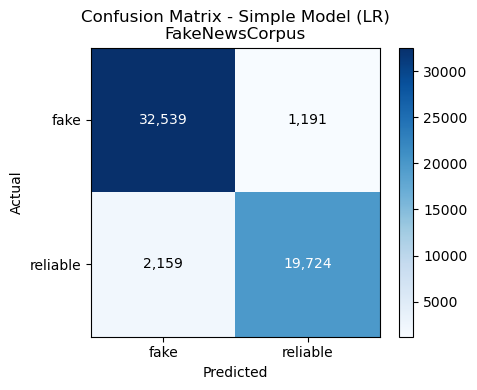

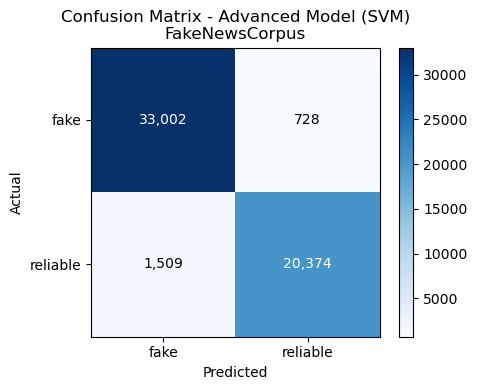

In [6]:
for y_pred, title in zip(
    [y_pred_lr, y_pred_svm],
    ["Simple Model (LR)", "Advanced Model (SVM)"]
):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["fake", "reliable"])
    ax.set_yticklabels(["fake", "reliable"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {title}\nFakeNewsCorpus")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 3. Task 2 - LIAR Dataset

In [7]:
# LIAR: no header, tab-separated. Column index 1 = label, index 2 = statement
def load_liar(path):
    df = pd.read_csv(path, sep="\t", header=None, usecols=[1, 2])
    df.columns = ["label_raw", "statement"]
    return df

liar_df = pd.concat([
    load_liar("LIAR_Dataset/train.tsv"),
    load_liar("LIAR_Dataset/valid.tsv"),
    load_liar("LIAR_Dataset/test.tsv"),
], ignore_index=True)

liar_df["statement"] = liar_df["statement"].fillna("")
print(f"LIAR samples: {len(liar_df):,}")
print(liar_df["label_raw"].value_counts())

LIAR samples: 12,791
label_raw
half-true      2627
false          2507
mostly-true    2454
barely-true    2103
true           2053
pants-fire     1047
Name: count, dtype: int64


In [ ]:
# Binary mapping - 0 = fake, 1 = reliable
# fake: pants-fire, false, barely-true
# reliable: half-true, mostly-true, true
fake_liar     = {"pants-fire", "false", "barely-true"}
reliable_liar = {"half-true", "mostly-true", "true"}

liar_df = liar_df[liar_df["label_raw"].isin(fake_liar | reliable_liar)].copy()
liar_df["label"] = liar_df["label_raw"].isin(reliable_liar).astype(int)

print(f"Samples after filtering: {len(liar_df):,}")
print(liar_df["label"].value_counts(normalize=True).rename({1: "reliable", 0: "fake"}).round(3))

Samples after filtering: 12,791
label
reliable    0.558
fake        0.442
Name: proportion, dtype: float64


In [9]:
y_liar = liar_df["label"].values

y_pred_liar_lr  = lr_pipeline.predict(liar_df["statement"])
y_pred_liar_svm = svm_clf.predict(svm_vec.transform(liar_df["statement"]))

report("Simple Model (LR) - LIAR",   y_liar, y_pred_liar_lr)
report("Advanced Model (SVM) - LIAR", y_liar, y_pred_liar_svm)

=== Simple Model (LR) - LIAR ===
Accuracy      : 0.4440
F1 (weighted) : 0.2806
F1 (macro)    : 0.3150
              precision    recall  f1-score   support

        fake       0.44      0.99      0.61      5657
    reliable       0.60      0.01      0.02      7134

    accuracy                           0.44     12791
   macro avg       0.52      0.50      0.31     12791
weighted avg       0.53      0.44      0.28     12791

=== Advanced Model (SVM) - LIAR ===
Accuracy      : 0.4749
F1 (weighted) : 0.3951
F1 (macro)    : 0.4164
              precision    recall  f1-score   support

        fake       0.45      0.89      0.60      5657
    reliable       0.63      0.14      0.23      7134

    accuracy                           0.47     12791
   macro avg       0.54      0.52      0.42     12791
weighted avg       0.55      0.47      0.40     12791



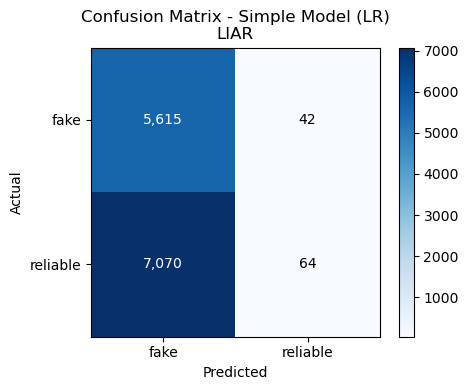

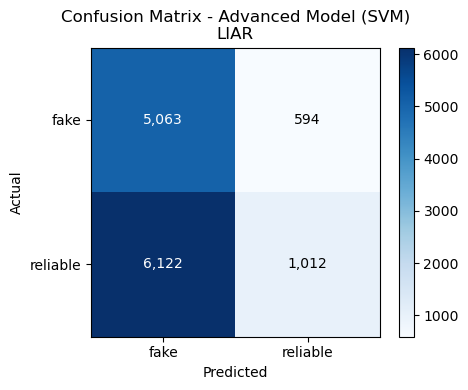

In [10]:
for y_pred, title in zip(
    [y_pred_liar_lr, y_pred_liar_svm],
    ["Simple Model (LR)", "Advanced Model (SVM)"]
):
    fig, ax = plt.subplots(figsize=(5, 4))
    cm = confusion_matrix(y_liar, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["fake", "reliable"])
    ax.set_yticklabels(["fake", "reliable"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {title}\nLIAR")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 4. Task 3 - Comparison Table

In [11]:
rows = [
    ("Simple (LR)",    "FakeNewsCorpus", y_test, y_pred_lr),
    ("Advanced (SVM)", "FakeNewsCorpus", y_test, y_pred_svm),
    ("Simple (LR)",    "LIAR",           y_liar, y_pred_liar_lr),
    ("Advanced (SVM)", "LIAR",           y_liar, y_pred_liar_svm),
]

records = []
for model, dataset, y_true, y_pred in rows:
    records.append({
        "Model":         model,
        "Dataset":       dataset,
        "Accuracy":      round(accuracy_score(y_true, y_pred), 4),
        "F1 (weighted)": round(f1_score(y_true, y_pred, average="weighted"), 4),
        "F1 (macro)":    round(f1_score(y_true, y_pred, average="macro"), 4),
    })

results_df = pd.DataFrame(records)
print(results_df.to_string(index=False))

         Model        Dataset  Accuracy  F1 (weighted)  F1 (macro)
   Simple (LR) FakeNewsCorpus    0.9398         0.9395      0.9364
Advanced (SVM) FakeNewsCorpus    0.9598         0.9596      0.9576
   Simple (LR)           LIAR    0.4440         0.2806      0.3150
Advanced (SVM)           LIAR    0.4749         0.3951      0.4164
